Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Happiness Rank                62 non-null     int64  
 1   Country                       62 non-null     object 
 2   Region                        62 non-null     object 
 3   Happiness Score               62 non-null     float64
 4   GDP per Capita                62 non-null     float64
 5   Social Support                62 non-null     float64
 6   Healthy Life Expectancy       62 non-null     float64
 7   Freedom to Make Life Choices  62 non-null     float64
 8   Generosity                    62 non-null     float64
 9   Perceptions of Corruption     62 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 5.0+ KB
None

First 5 Rows:
   Happiness Rank        Country                 Region  Happiness Score  \
0               1

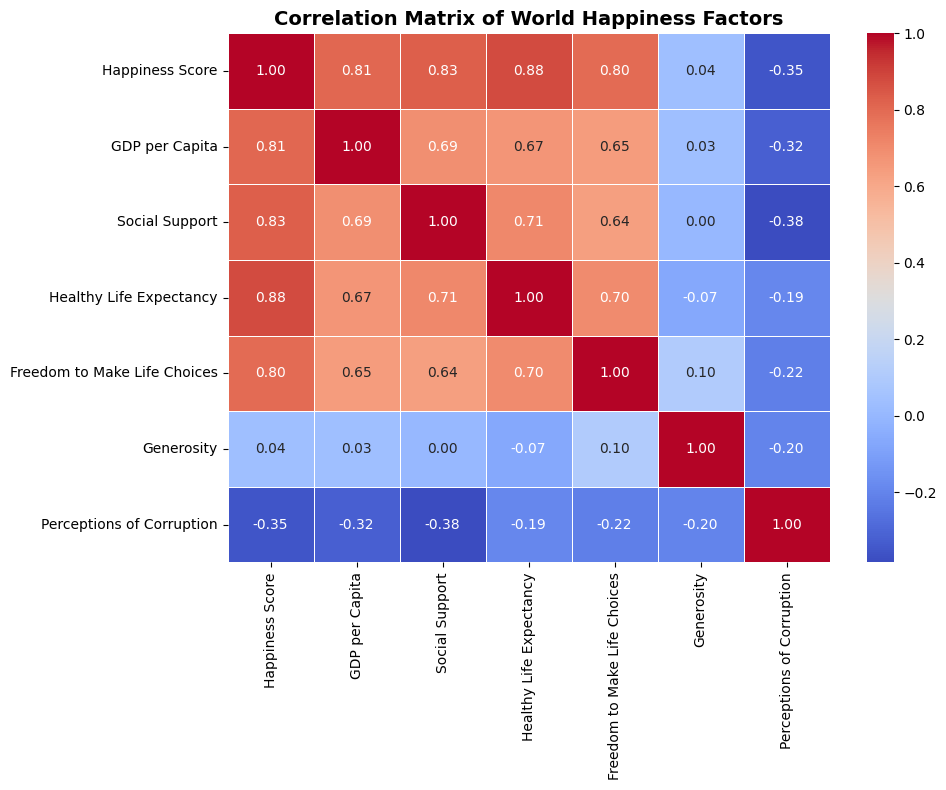

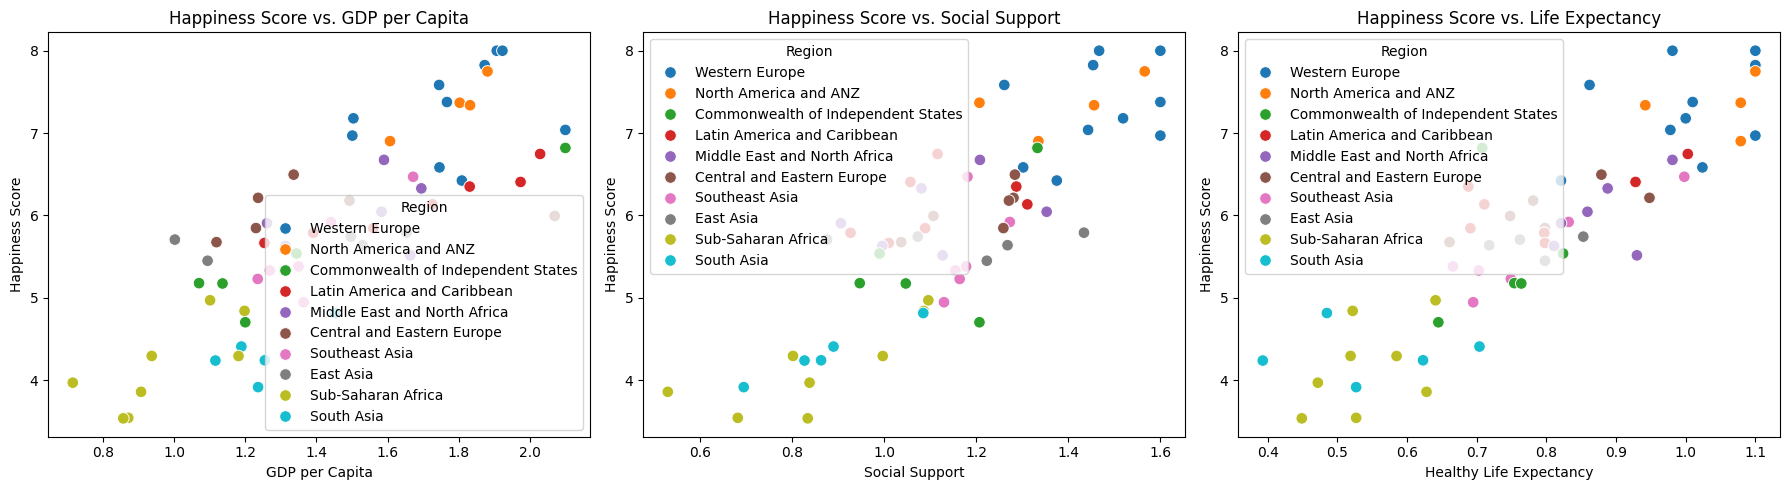


Top 5 Happiest Countries:
         Country  Happiness Score                 Region
0        Finland            8.000         Western Europe
1        Ireland            8.000         Western Europe
2         Norway            7.825         Western Europe
3  United States            7.749  North America and ANZ
4        Austria            7.584         Western Europe

Bottom 5 Countries:
         Country  Happiness Score              Region
57        Zambia            3.968  Sub-Saharan Africa
58    Bangladesh            3.914          South Asia
59  South Africa            3.857  Sub-Saharan Africa
60         Kenya            3.541  Sub-Saharan Africa
61      Tanzania            3.535  Sub-Saharan Africa


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("world_happiness_report.csv")

# Display initial data structure
print("Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# 2. Data Cleaning & Inspection
# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Drop irrelevant text columns for correlation analysis
numeric_df = df.select_dtypes(include=["float64", "int64"]).drop(
    columns=["Happiness Rank"], errors="ignore"
)

# 3. Correlation Matrix & Heatmap Analysis
plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title(
    "Correlation Matrix of World Happiness Factors",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# 4. Feature Visualization: Scatter Plots
# Analyzing relationship between Happiness Score and key factors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GDP per Capita vs Happiness Score
sns.scatterplot(
    data=df,
    x="GDP per Capita",
    y="Happiness Score",
    hue="Region",
    ax=axes[0],
    s=70,
)
axes[0].set_title("Happiness Score vs. GDP per Capita")

# Social Support vs Happiness Score
sns.scatterplot(
    data=df,
    x="Social Support",
    y="Happiness Score",
    hue="Region",
    ax=axes[1],
    s=70,
)
axes[1].set_title("Happiness Score vs. Social Support")

# Healthy Life Expectancy vs Happiness Score
sns.scatterplot(
    data=df,
    x="Healthy Life Expectancy",
    y="Happiness Score",
    hue="Region",
    ax=axes[2],
    s=70,
)
axes[2].set_title("Happiness Score vs. Life Expectancy")

plt.tight_layout()
plt.show()

# 5. Top & Bottom 5 Countries Analysis
print("\nTop 5 Happiest Countries:")
print(df[["Country", "Happiness Score", "Region"]].head(5))

print("\nBottom 5 Countries:")
print(df[["Country", "Happiness Score", "Region"]].tail(5))